In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('/content/gurgaon_properties_outliers_treated .csv')

In [5]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,breez global hill view,sohna road,0.30,5128.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,11.0,North,New Property,NaN,NaN,585.448521,0,0,0,0,0,1,91.0,292.5
1,flat,aipl club residences,sector 70a,0.95,10215.0,930.0,Built Up area: 930 (86.4 sq.m.)Carpet area: 73...,2,2,1,11.0,North-East,New Property,NaN,930.0,730.000000,0,0,0,0,0,2,103.0,465.0
2,house,nirvana cedar crest,sector 50,7.10,32870.0,2160.0,Plot area 240(200.67 sq.m.)Built Up area: 239 ...,5,4,3,2.0,East,Moderately Old,NaN,239.0,238.000000,1,0,1,1,0,2,110.0,432.0
3,house,independent,sector 25,13.50,37313.0,3618.0,Plot area 402(336.12 sq.m.),5,6,3+,4.0,North-East,Old Property,NaN,3618.0,NaN,0,0,0,0,1,2,79.0,723.6
4,house,independent,sector 50,10.56,32593.0,3240.0,Plot area 360(301.01 sq.m.),5,5,3,3.0,NaN,Moderately Old,NaN,3240.0,NaN,0,1,0,0,0,1,20.0,648.0


In [6]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


# Built up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

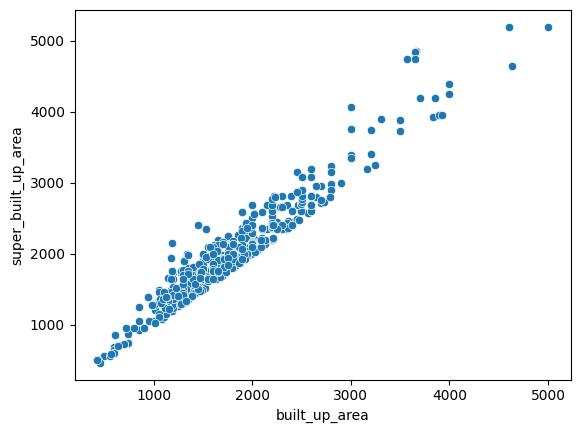

In [7]:
sns.scatterplot(x=df['built_up_area'], y=df['super_built_up_area'])

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

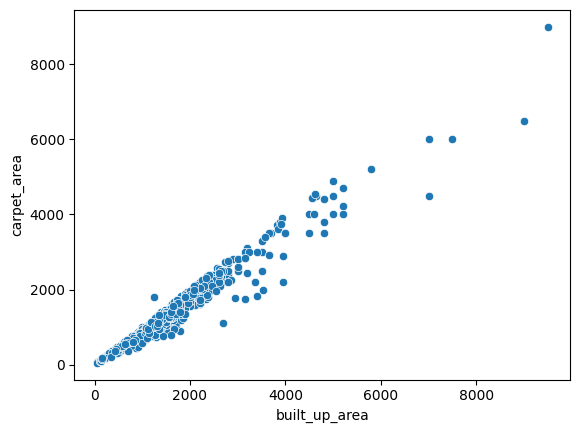

In [8]:
sns.scatterplot(x=df['built_up_area'], y=df['carpet_area'])

In [9]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

,0
0,False
1,False
2,False
3,False
4,False
...,...
3553,False
3554,False
3555,False
3556,False


In [10]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [11]:
all_present_df.shape

(531, 24)

In [12]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [13]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [14]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.105263157894737 0.9


In [15]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [16]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
10,flat,m3m latitude,sector 65,4.70,19748.0,2380.0,Super Built up area 2380(221.11 sq.m.)Carpet a...,3,3,3+,9.0,North-East,Relatively New,2380.0,NaN,1231.00,0,1,0,1,0,2,44.0,793.333333
20,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Carpet a...,3,3,3,6.0,North-West,Relatively New,1900.0,NaN,1240.04,0,1,0,0,0,2,105.0,633.333333
21,flat,viridian the plaza 106,sector 106,0.39,5571.0,700.0,Super Built up area 700(65.03 sq.m.)Carpet are...,1,1,1,7.0,East,Relatively New,700.0,NaN,450.00,0,0,0,0,0,1,130.0,700.000000
25,flat,hero homes,sector 104,1.40,15819.0,885.0,Super Built up area 1389(129.04 sq.m.)Carpet a...,3,2,2,4.0,North,Undefined,1389.0,NaN,884.58,0,0,0,0,0,1,49.0,295.000000
46,flat,emaar mgf palm hills,sector 77,1.25,8621.0,1450.0,Super Built up area 1450(134.71 sq.m.)Carpet a...,3,4,3,3.0,North,Relatively New,1450.0,NaN,1177.00,1,1,0,0,0,1,49.0,483.333333


In [17]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

<ipython-input-17-a2fefc960aa3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
<ipython-input-17-a2fefc960aa3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_

In [18]:
df.update(sbc_df)

In [19]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [20]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [21]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
7,flat,orchid petals,sector 49,2.45,11887.0,2061.0,Super Built up area 2061(191.47 sq.m.),3,3,3,0.0,North-East,Relatively New,2061.0,NaN,NaN,1,0,0,0,0,1,49.0,687.000000
11,flat,chd avenue,sector 71,1.12,6215.0,1802.0,Super Built up area 1802(167.41 sq.m.),3,4,3,0.0,South-East,Moderately Old,1802.0,NaN,NaN,0,1,0,0,0,1,65.0,600.666667
13,flat,bestech park view residency,sector 2,1.55,8073.0,1920.0,Super Built up area 1920(178.37 sq.m.),3,4,3+,4.0,East,Old Property,1920.0,NaN,NaN,0,1,0,0,0,1,84.0,640.000000
14,flat,central park flower valley,sector 33,2.20,10476.0,2100.0,Super Built up area 2100(195.1 sq.m.),3,3,3,12.0,North-East,New Property,2100.0,NaN,NaN,0,1,0,0,0,2,49.0,700.000000
15,flat,parkwood westend,sector 92,0.70,5204.0,1345.0,Super Built up area 1345(124.95 sq.m.),2,2,3,5.0,NaN,Under Construction,1345.0,NaN,NaN,1,0,0,0,0,1,0.0,672.500000


In [22]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

<ipython-input-22-554030e2e595>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
<ipython-input-22-554030e2e595>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [23]:
df.update(sb_df)

In [24]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [25]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,breez global hill view,sohna road,0.30,5128.0,585.0,Carpet area: 585.41 (54.39 sq.m.),2,2,1,11.0,North,New Property,NaN,NaN,585.448521,0,0,0,0,0,1,91.0,292.500000
8,flat,birla navya,sector 63a,3.15,14631.0,2153.0,Carpet area: 200,3,3,3,4.0,East,Undefined,NaN,NaN,200.000000,0,0,0,0,1,1,44.0,717.666667
9,flat,godrej,sector 79,2.00,8453.0,2366.0,Carpet area: 2366 (219.81 sq.m.),3,4,3+,2.0,North-East,Relatively New,NaN,NaN,2366.000000,0,1,0,0,0,2,156.0,788.666667
26,flat,godrej summit,sector 104,1.75,7530.0,2324.0,Carpet area: 2324 (215.91 sq.m.),4,5,3+,1.0,NaN,New Property,NaN,NaN,2324.000000,0,1,0,0,0,1,60.0,581.000000
28,flat,signature global park,sohna road,0.56,6813.0,822.0,Carpet area: 822 (76.37 sq.m.),2,2,3,3.0,South,New Property,NaN,NaN,822.000000,0,0,0,0,0,1,81.0,411.000000


In [27]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

<ipython-input-27-747bc7ee3c0e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
<ipython-input-27-747bc7ee3c0e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)


In [28]:
df.update(c_df)

In [29]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [36]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [37]:
anamoly_df.sample(5)

,price,area,built_up_area
925,4.85,1875.0,1697.0
553,3.00,1975.0,1787.0
295,4.50,1350.0,1350.0
2526,2.85,1828.0,1654.0
2476,2.79,1860.0,1564.0


In [38]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [39]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

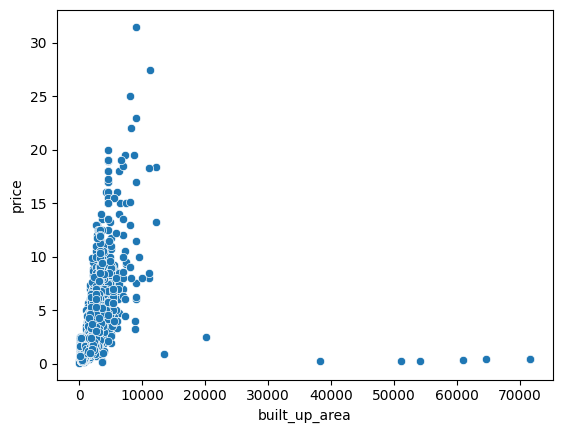

In [40]:
sns.scatterplot(x=df['built_up_area'],y=df['price'])

In [41]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [42]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,breez global hill view,sohna road,0.30,5128.0,2,2,1,11.0,North,New Property,650.0,0,0,0,0,0,1,91.0
1,flat,aipl club residences,sector 70a,0.95,10215.0,2,2,1,11.0,North-East,New Property,930.0,0,0,0,0,0,2,103.0
2,house,nirvana cedar crest,sector 50,7.10,32870.0,5,4,3,2.0,East,Moderately Old,2160.0,1,0,1,1,0,2,110.0
3,house,independent,sector 25,13.50,37313.0,5,6,3+,4.0,North-East,Old Property,3618.0,0,0,0,0,1,2,79.0
4,house,independent,sector 50,10.56,32593.0,5,5,3,3.0,NaN,Moderately Old,3240.0,0,1,0,0,0,1,20.0


In [43]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,17
facing,1011


# floorNum

In [44]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
283,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,1,0.0
750,flat,NaN,sector 78,0.60,3692.0,2,2,0,NaN,NaN,Under Construction,1625.0,0,0,0,0,0,1,103.0
771,house,independent,sector 4,0.65,11111.0,4,2,2,NaN,NaN,Moderately Old,585.0,0,0,0,0,0,1,0.0
835,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,1,0.0
1575,house,emaar mgf marbella,sector 66,9.00,21251.0,4,4,3+,NaN,South-West,Relatively New,5200.0,0,1,1,1,0,2,63.0
1577,house,independent,sector 25,13.00,45710.0,6,8,3+,NaN,NaN,Relatively New,2844.0,1,1,1,1,0,0,0.0
1836,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,1,174.0
1974,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,1,45.0
2086,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,1,53.0
2140,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,2,NaN,East,Moderately Old,3240.0,0,1,1,1,0,1,49.0


In [45]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [46]:
df['floorNum'].fillna(2.0,inplace=True)

<ipython-input-46-4d4ca364c16c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [47]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,1011


In [49]:
1011/df.shape[0]

0.28414839797639124

# facing

<Axes: ylabel='count'>

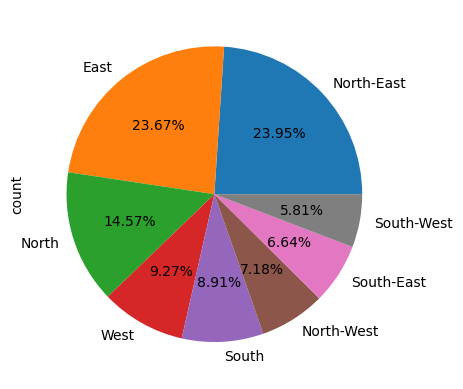

In [48]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [50]:
df.drop(columns=['facing'],inplace=True)

In [51]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3505,flat,ss the leaf,sector 85,2.00,8306.0,3,4,3,8.0,Relatively New,2179.0,0,1,0,0,0,1,NaN
2115,flat,emaar mgf the palm drive,sector 66,3.98,18091.0,3,4,3+,2.0,Moderately Old,2200.0,0,1,0,0,0,2,174.0
2957,flat,puri diplomatic greens,sector 111,3.90,13000.0,4,5,3+,6.0,Relatively New,2996.0,0,1,0,0,0,0,0.0
1520,flat,signature global city,sector 37d,1.10,8800.0,3,3,3,1.0,Undefined,1389.0,0,0,0,0,0,1,61.0
1011,flat,shapoorji pallonji joyville gurugram,sector 102,1.28,10535.0,2,2,3,10.0,Relatively New,1100.0,0,0,0,0,0,1,60.0


In [52]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [53]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
750,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,1,103.0


In [54]:
df.drop(index=[750],inplace=True)

In [55]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


# agePossession

In [56]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1610
New Property,556
Moderately Old,543
Undefined,431
Old Property,292
Under Construction,125


In [57]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
8,flat,birla navya,sector 63a,3.15,14631.0,3,3,3,4.0,Undefined,2153.0,0,0,0,0,1,1,44.0
17,flat,dnha cghs,sector 1,0.85,3864.0,3,3,0,5.0,Undefined,2200.0,0,0,0,0,0,1,0.0
23,house,dlf floors phase 3,sector 24,3.51,12342.0,4,4,3,4.0,Undefined,2844.0,1,1,1,1,0,2,160.0
25,flat,hero homes,sector 104,1.40,15819.0,3,2,2,4.0,Undefined,1120.0,0,0,0,0,0,1,49.0
34,flat,shapoorji pallonji joyville gurugram,sector 102,1.05,11475.0,2,2,2,0.0,Undefined,1017.0,0,0,0,0,0,1,49.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3516,flat,raheja vedaanta,sector 108,1.00,4854.0,2,2,2,0.0,Undefined,2060.0,0,0,0,0,0,1,NaN
3550,flat,m3m heights,sector 65,3.67,17990.0,3,3,2,27.0,Undefined,2040.0,0,1,0,0,0,1,NaN
3551,house,independent,sector 7,3.00,11494.0,7,7,0,3.0,Undefined,2610.0,0,0,0,0,0,1,NaN
3552,flat,sare petioles,sector 92,1.25,6098.0,3,3,3,18.0,Undefined,2278.0,0,1,0,0,0,1,NaN


In [58]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [59]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [60]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1799
New Property,623
Moderately Old,586
Old Property,328
Under Construction,131
Undefined,90


In [61]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [62]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [63]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1815
New Property,645
Moderately Old,593
Old Property,339
Under Construction,131
Undefined,34


In [64]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [65]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [66]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1826
New Property,645
Moderately Old,616
Old Property,339
Under Construction,131


In [67]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [70]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [69]:
df.shape

(3557, 18)